In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["font.family"] = 'serif'
plt.rcParams["font.serif"] = ["cmr10"]
plt.rcParams["mathtext.fontset"]='cm'
plt.rcParams["font.size"] = 8
cm_to_inch=1/2.54
fig_size = (8.7*cm_to_inch,6*cm_to_inch)

# CD Data

In [3]:
df_cd = pl.read_csv('Raw data/260105 seeded/tempdep_data_7D_CD_to_Max.txt',separator='\t')
df_cd

wavelength/nm,10,10_duplicated_0,22,22_duplicated_0,37,37_duplicated_0,60,60_duplicated_0,80,10 av,22 av,37 av,60 av,80 av
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
250.0,0.015048,0.012976,0.016437,0.025402,0.00927,0.012,0.01309,0.015433,0.021555,0.014012,0.02092,0.010635,0.014262,0.021555
249.0,-0.001084,-0.009402,0.002916,0.006382,-0.00559,-0.00454,0.00018,-0.002931,0.003595,-0.005243,0.004649,-0.005065,-0.001375,0.003595
248.0,-0.022953,-0.034719,-0.025184,-0.048332,-0.02837,-0.01337,-0.01037,-0.036782,-0.014243,-0.028836,-0.036758,-0.02087,-0.023576,-0.014243
247.0,-0.051352,-0.067859,-0.072061,-0.0413,-0.06262,-0.01141,-0.03603,-0.052248,-0.051745,-0.059606,-0.05668,-0.037015,-0.044139,-0.051745
246.0,-0.070949,-0.10282,-0.099794,-0.069198,-0.09083,-0.0813,-0.04272,-0.11304,-0.051205,-0.086882,-0.084496,-0.086065,-0.077882,-0.051205
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
189.0,10.007,9.4488,9.9288,11.37,13.273,11.536,4.2577,4.0257,0.88255,9.7277,10.649,12.405,4.1417,0.88255
188.0,8.4212,8.28,8.7104,9.9833,11.888,9.7435,3.6434,3.2309,0.65707,8.3506,9.3468,10.816,3.4372,0.65707
187.0,6.9956,6.5321,6.8093,8.734,10.212,8.694,3.1385,2.7837,0.37337,6.7639,7.7717,9.4532,2.9611,0.37337


In [4]:
df_cd.select( '^10.*$')

10,10_duplicated_0,10 av
f64,f64,f64
0.015048,0.012976,0.014012
-0.001084,-0.009402,-0.005243
-0.022953,-0.034719,-0.028836
-0.051352,-0.067859,-0.059606
-0.070949,-0.10282,-0.086882
…,…,…
10.007,9.4488,9.7277
8.4212,8.28,8.3506
6.9956,6.5321,6.7639


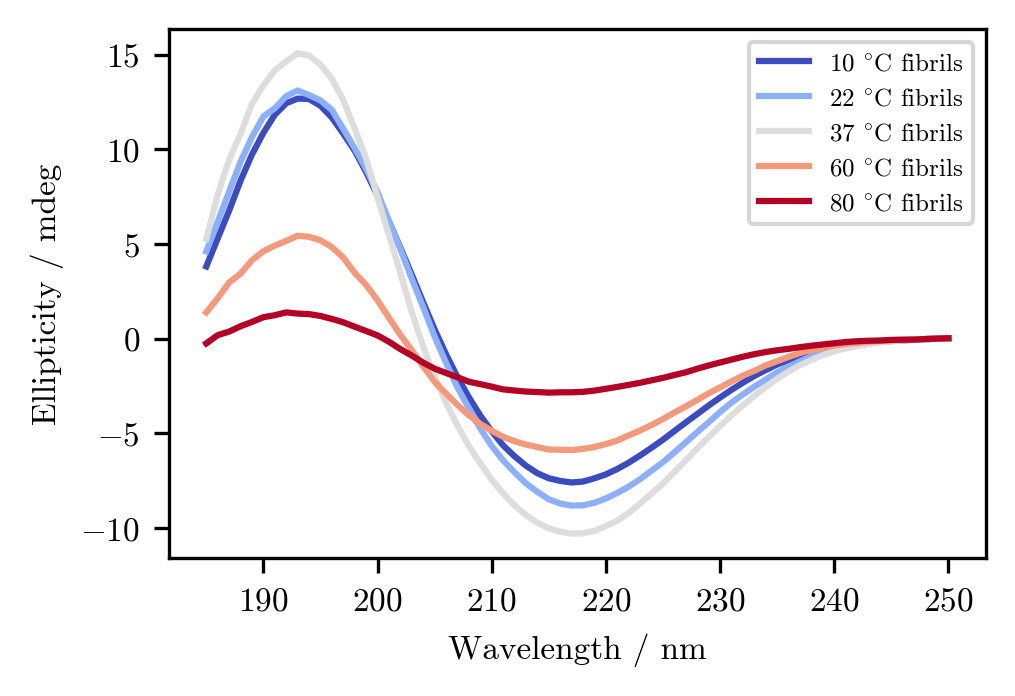

In [5]:
cmp = plt.get_cmap('coolwarm',5)
plt.figure(figsize=fig_size)
for i,temp in enumerate([10,22,37,60,80]):
    plt.plot(df_cd['wavelength/nm'],df_cd[str(temp)+' av'],label=str(temp)+r' $^{\circ}$C fibrils',color=cmp(i))
plt.legend(fontsize=6)
#plt.xlim(200,240)
plt.xlabel('Wavelength / nm')
plt.ylabel('Ellipticity / mdeg')
plt.tight_layout()
plt.savefig('plots/CD-spectra-new.pdf')

In [6]:
df_cd[:,1:10]#.select(~pl.col('^.*av$'))

10,10_duplicated_0,22,22_duplicated_0,37,37_duplicated_0,60,60_duplicated_0,80
f64,f64,f64,f64,f64,f64,f64,f64,f64
0.015048,0.012976,0.016437,0.025402,0.00927,0.012,0.01309,0.015433,0.021555
-0.001084,-0.009402,0.002916,0.006382,-0.00559,-0.00454,0.00018,-0.002931,0.003595
-0.022953,-0.034719,-0.025184,-0.048332,-0.02837,-0.01337,-0.01037,-0.036782,-0.014243
-0.051352,-0.067859,-0.072061,-0.0413,-0.06262,-0.01141,-0.03603,-0.052248,-0.051745
-0.070949,-0.10282,-0.099794,-0.069198,-0.09083,-0.0813,-0.04272,-0.11304,-0.051205
…,…,…,…,…,…,…,…,…
10.007,9.4488,9.9288,11.37,13.273,11.536,4.2577,4.0257,0.88255
8.4212,8.28,8.7104,9.9833,11.888,9.7435,3.6434,3.2309,0.65707
6.9956,6.5321,6.8093,8.734,10.212,8.694,3.1385,2.7837,0.37337


In [7]:
def legend_without_duplicate_labels(ax):
    # Solution from https://stackoverflow.com/a/56253636
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique),fontsize=6)

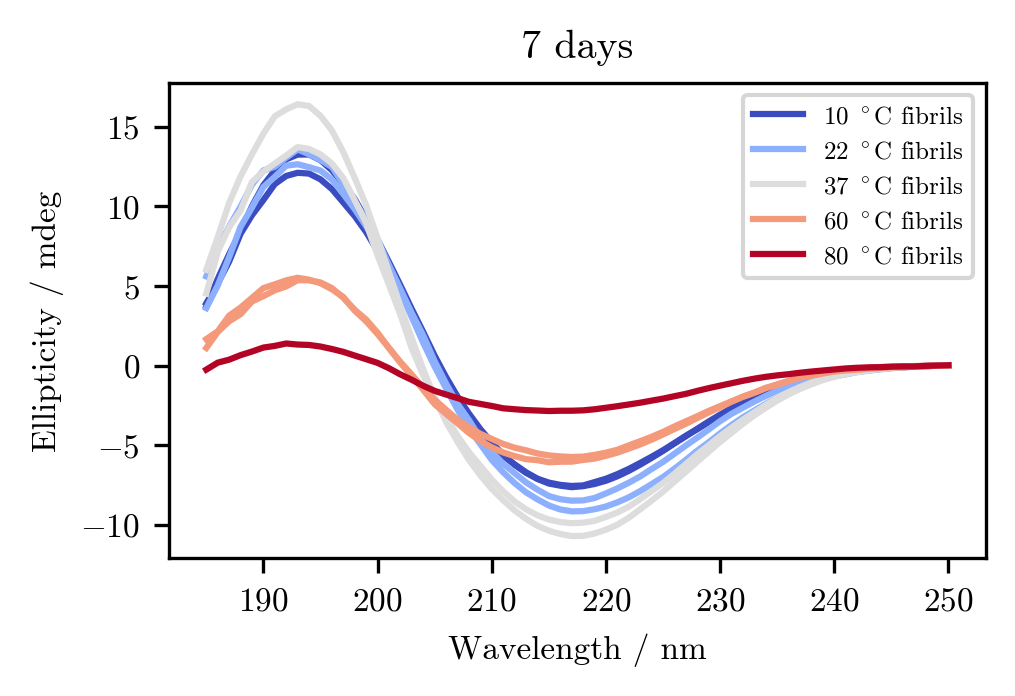

In [8]:
cmp = plt.get_cmap('coolwarm',5)
fig, ax1 = plt.subplots(1,figsize=fig_size)
for i,temp in enumerate([10,22,37,60,80]):
    ax1.plot(df_cd['wavelength/nm'],df_cd[:,1:10].select('^'+str(temp)+'.*$'),label=str(temp)+r' $^\circ$C fibrils',color=cmp(i))
legend_without_duplicate_labels(ax1)
#plt.xlim(200,240)
plt.xlabel('Wavelength / nm')
plt.ylabel('Ellipticity / mdeg')
plt.title('7 days')
plt.tight_layout()
plt.savefig('plots/CD-spectra-new-7d-SI.pdf')

In [9]:
df_cd2 = pl.read_csv('Raw data/260105 seeded/tempdep_data_2D_CD_to_Max.txt',separator='\t')
df_cd2

wavelength / nm,10,10_duplicated_0,22,22_duplicated_0,37,37_duplicated_0,60,60_duplicated_0,80,80_duplicated_0,10 av,22 av,37 av,60 av,80 av
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
250.0,0.0006089,0.0070731,0.0099553,-0.012743,0.027432,0.006546,-0.014712,0.010703,-0.002143,0.013183,0.003841,-0.001394,0.016989,-0.002005,0.0055203
249.0,-0.003161,-0.000221,-0.030171,-0.01065,-0.015151,-0.01654,-0.018006,-0.012801,-0.008443,-0.013248,-0.001691,-0.02041,-0.015845,-0.015403,-0.010845
248.0,-0.004545,-0.009136,-0.056678,-0.041876,-0.049079,-0.050469,-0.039291,-0.051273,-0.030417,-0.036232,-0.006841,-0.049277,-0.049774,-0.045282,-0.033324
247.0,-0.0228,-0.022551,-0.080046,-0.065727,-0.061881,-0.060774,-0.077219,-0.068669,-0.04446,-0.060296,-0.022675,-0.072886,-0.061328,-0.072944,-0.052378
246.0,-0.042576,-0.044319,-0.10262,-0.094785,-0.10808,-0.10504,-0.089745,-0.10451,-0.043072,-0.072433,-0.043447,-0.098702,-0.10656,-0.097129,-0.057753
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
189.0,4.2286,5.2403,9.7291,8.9126,10.743,10.591,4.2526,3.6932,1.0828,1.2388,4.7345,9.3209,10.667,3.9729,1.1608
188.0,3.5287,4.6163,8.2727,7.6682,9.1853,9.2085,3.6129,2.8668,0.83709,0.97348,4.0725,7.9705,9.1969,3.2399,0.90528
187.0,2.8349,3.7769,6.6894,6.3638,7.9139,7.7207,2.9375,2.2433,0.67707,0.75245,3.3059,6.5266,7.8173,2.5904,0.71476


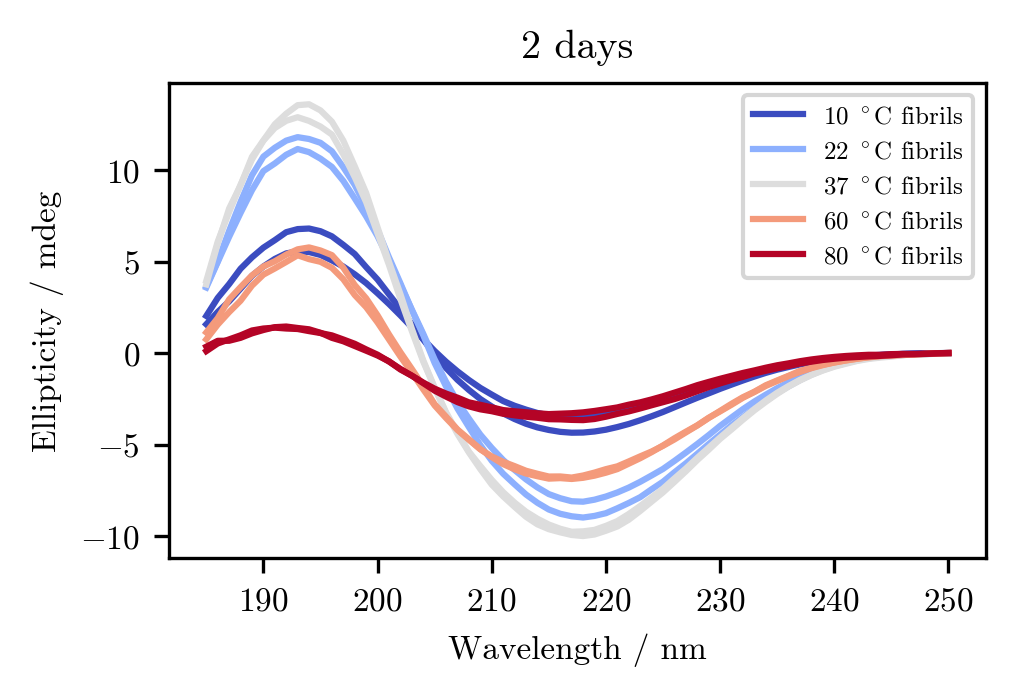

In [10]:
cmp = plt.get_cmap('coolwarm',5)
fig, ax1 = plt.subplots(1,figsize=fig_size)
for i,temp in enumerate([10,22,37,60,80]):
    ax1.plot(df_cd2['wavelength / nm'],df_cd2[:,1:11].select('^'+str(temp)+'.*$'),label=str(temp)+r' $^\circ$C fibrils',color=cmp(i))
legend_without_duplicate_labels(ax1)
#plt.legend()
#plt.xlim(200,240)
plt.xlabel('Wavelength / nm')
plt.ylabel('Ellipticity / mdeg')
plt.title('2 days')
plt.tight_layout()
plt.savefig('plots/CD-spectra-new-2d-SI.pdf')

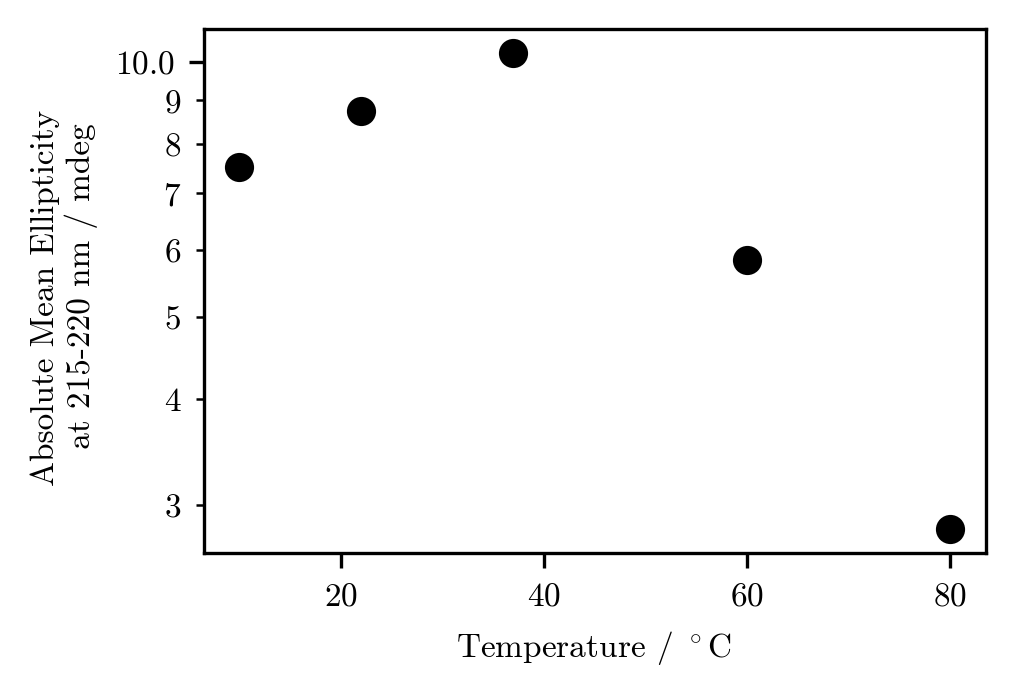

In [11]:
fig, ax2 = plt.subplots(1,figsize=fig_size)

ax2.scatter([10,22,37,60,80],
            df_cd.filter(pl.col('wavelength/nm')>215
            ).filter(pl.col('wavelength/nm')<220
                    ).mean().select( pl.col('^.*av$').abs())
           ,color='black')
ax2.semilogy()
#ax2.set_ylim(3,9)
ax2.set_xlabel(r'Temperature / $^\circ$C ')
ax2.set_ylabel('Absolute Mean Ellipticity \n at 215-220 nm / mdeg')
ax2.get_yaxis().set_minor_formatter(ticker.ScalarFormatter())
ax2.get_yaxis().set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.savefig('plots/mean ellipticity new.pdf')